<a href="https://colab.research.google.com/github/tarannump096-cpu/NLP/blob/main/Medical_Insurance_Cost_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd

In [3]:
df=pd.read_csv("/content/medical_insurance.csv")

In [4]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
2767,47,female,45.320,1,no,southeast,8569.86180
2768,21,female,34.600,0,no,southwest,2020.17700
2769,19,male,26.030,1,yes,northwest,16450.89470
2770,23,male,18.715,0,no,northwest,21595.38229


In [5]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='age', ylabel='charges'>

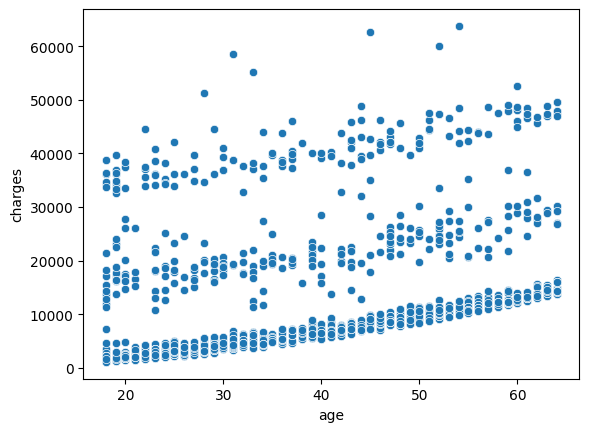

In [7]:
sns.scatterplot(x="age",y="charges",data=df)

In [8]:
from scipy.stats import pearsonr

In [9]:
v1=pearsonr(df["age"],df["charges"])

In [10]:
v1

PearsonRResult(statistic=np.float64(0.29862366562936266), pvalue=np.float64(3.3160729998345e-58))

In [11]:
from scipy.stats import spearmanr

In [12]:
v2=spearmanr(df["age"],df["charges"])

In [13]:
v2

SignificanceResult(statistic=np.float64(0.5358797599935969), pvalue=np.float64(6.905661241953329e-206))

In [14]:
df["age_sq"]=df["age"]**2

<Axes: xlabel='age_sq', ylabel='charges'>

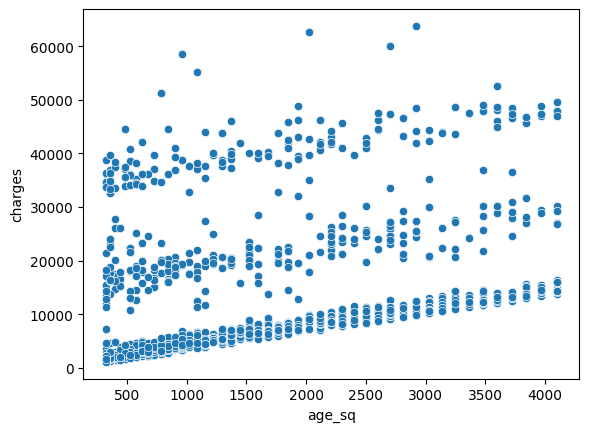

In [15]:
sns.scatterplot(x="age_sq",y="charges",data=df)

/tmp/ipykernel_12269/3454039009.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["charges"])


<Axes: xlabel='charges', ylabel='Density'>

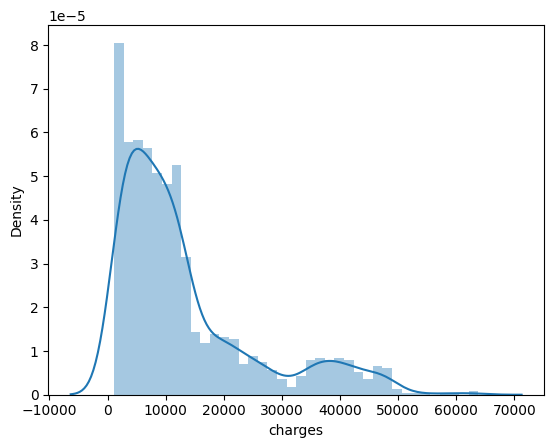

In [16]:
sns.distplot(df["charges"])

In [17]:
df["charges_log"]=np.log(df["charges"])

/tmp/ipykernel_12269/1907057310.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["charges_log"])


<Axes: xlabel='charges_log', ylabel='Density'>

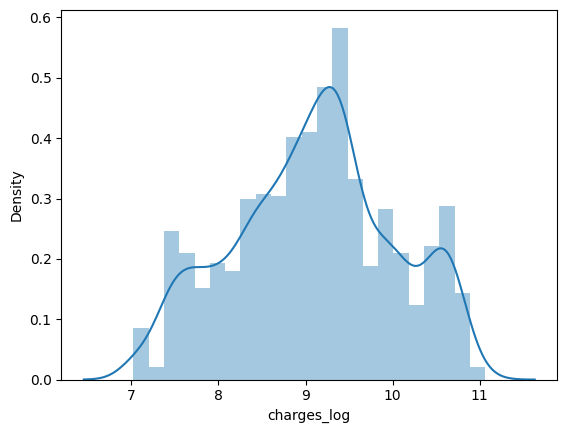

In [18]:
sns.distplot(df["charges_log"])

<Axes: xlabel='age_sq', ylabel='charges_log'>

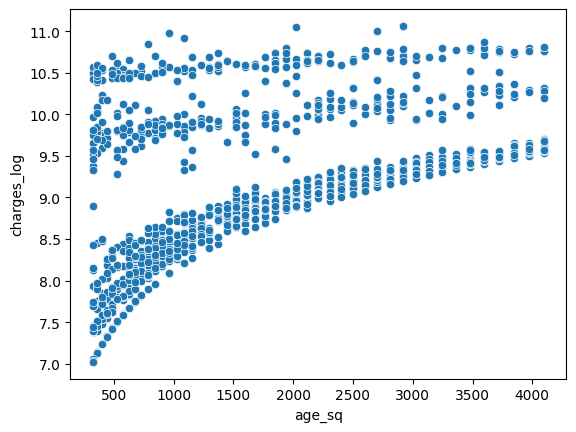

In [19]:
sns.scatterplot(x="age_sq",y="charges_log",data=df)

In [20]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges',
       'age_sq', 'charges_log'],
      dtype='object')

<Axes: xlabel='sex', ylabel='charges'>

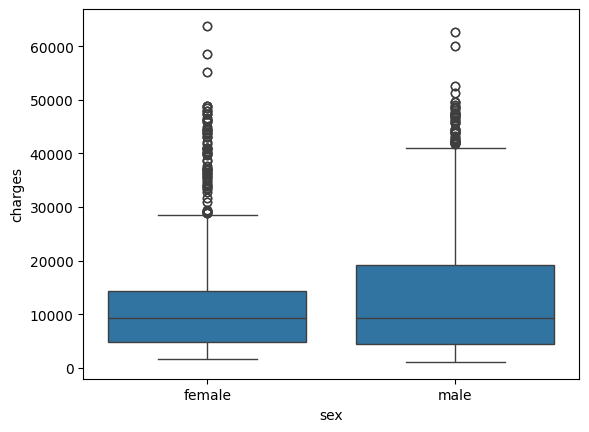

In [21]:
sns.boxplot(x="sex",y="charges",data=df)

In [22]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges',
       'age_sq', 'charges_log'],
      dtype='object')

In [23]:
def bmi_cat(x):
    if x<18.5:
        return "underweight"
    elif x>18.5 and x<=25:
        return "normal"
    elif x>25 and x<=30:
        return "overweight"
    else:
        return "Obese"

In [24]:
df["bmi_cat"]=df["bmi"].apply(bmi_cat)

<Axes: xlabel='bmi_cat', ylabel='charges'>

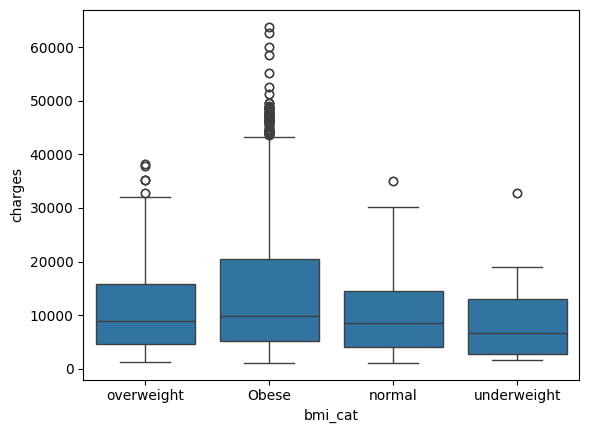

In [25]:
sns.boxplot(x=df["bmi_cat"],y=df["charges"],data=df)

<Axes: xlabel='bmi', ylabel='charges_log'>

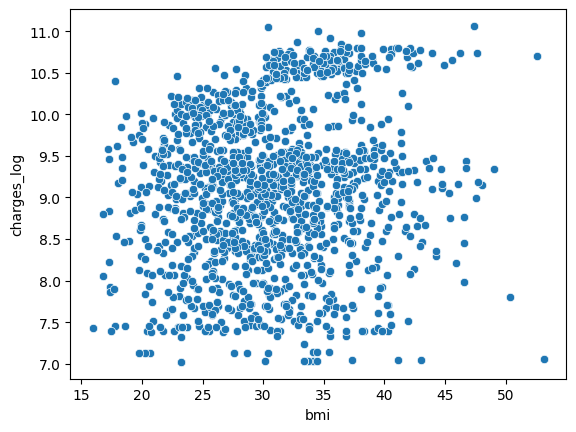

In [26]:
sns.scatterplot(x="bmi",y="charges_log",data=df)

In [27]:
df["bmi_sq"]=df["bmi"]**2

<Axes: xlabel='bmi_sq', ylabel='charges_log'>

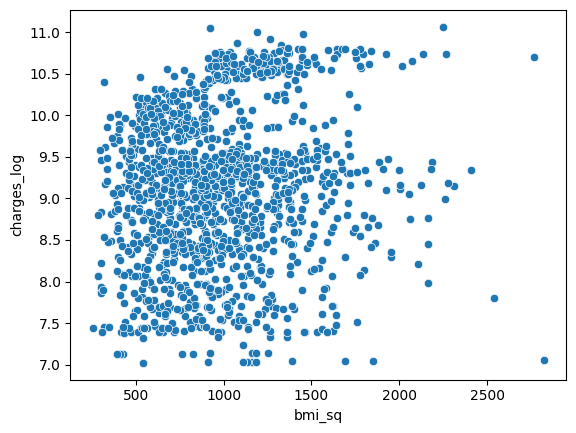

In [29]:
sns.scatterplot(x="bmi_sq",y="charges_log",data=df)


In [30]:
df["age&bmi"]=df["age"]*df["bmi"]

<Axes: xlabel='age&bmi', ylabel='charges_log'>

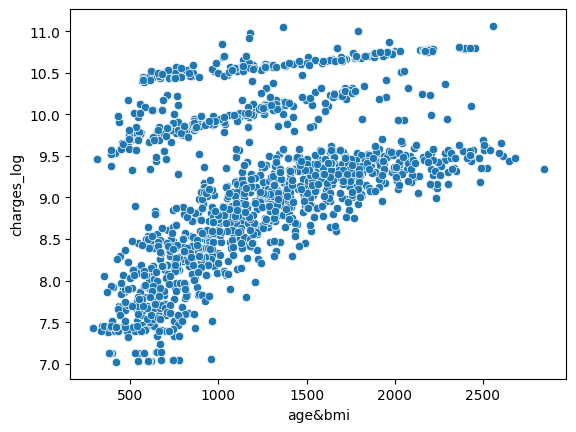

In [31]:
sns.scatterplot(x="age&bmi",y="charges_log",data=df)

In [32]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges',
       'age_sq', 'charges_log', 'bmi_cat', 'bmi_sq', 'age&bmi'],
      dtype='object')

In [33]:
df["children"]=df["children"]+1

In [34]:
df["children"].unique()

array([1, 2, 4, 3, 6, 5])

In [35]:
def family(x):
    if x<=3:
        return "small_family"
    else:
        return "large_family"

In [36]:
df["family"]=df["children"].apply(family)

In [37]:
df["family"].value_counts()

,count
family,
small_family,2354
large_family,418


<Axes: xlabel='family', ylabel='charges'>

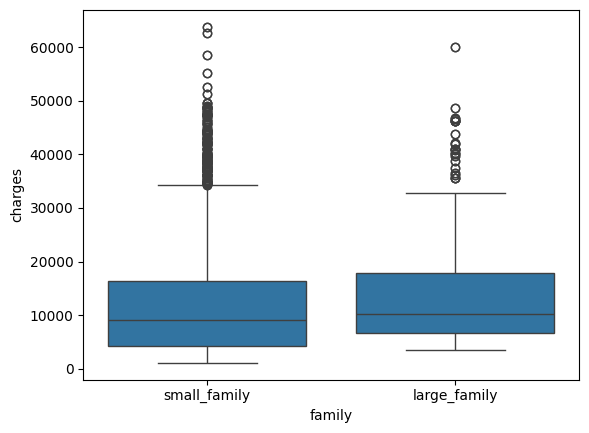

In [38]:
sns.boxplot(x=df["family"],y=df["charges"],data=df)

In [39]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges',
       'age_sq', 'charges_log', 'bmi_cat', 'bmi_sq', 'age&bmi', 'family'],
      dtype='object')

<Axes: xlabel='smoker', ylabel='charges'>

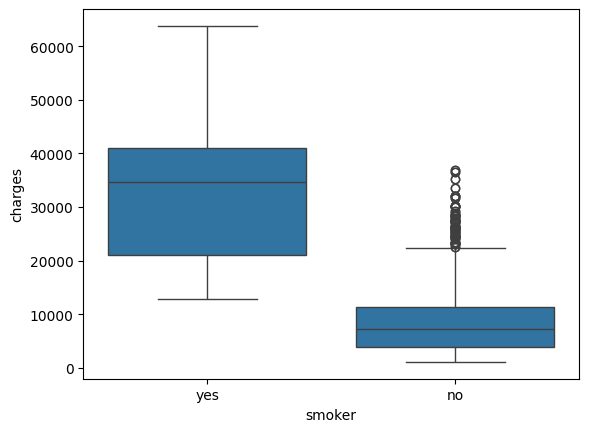

In [40]:
sns.boxplot(x="smoker",y="charges",data=df)

In [41]:
df1=pd.read_csv("/content/medical_insurance.csv")

In [42]:
df1

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
2767,47,female,45.320,1,no,southeast,8569.86180
2768,21,female,34.600,0,no,southwest,2020.17700
2769,19,male,26.030,1,yes,northwest,16450.89470
2770,23,male,18.715,0,no,northwest,21595.38229


In [43]:
df1.drop(columns=["region"],inplace=True)

In [44]:
def convert_cat(x):
    if x=="male":
        return 0
    else:
        return 1

In [45]:
df1["sex"]=df1["sex"].apply(convert_cat)

In [46]:
def smoker(x):
    if x=="yes":
        return 1
    else:
        return 0

In [47]:
df1["smoker"]=df1["smoker"].apply(smoker)

In [48]:
df1

,age,sex,bmi,children,smoker,charges
0,19,1,27.900,0,1,16884.92400
1,18,0,33.770,1,0,1725.55230
2,28,0,33.000,3,0,4449.46200
3,33,0,22.705,0,0,21984.47061
4,32,0,28.880,0,0,3866.85520
...,...,...,...,...,...,...
2767,47,1,45.320,1,0,8569.86180
2768,21,1,34.600,0,0,2020.17700
2769,19,0,26.030,1,1,16450.89470
2770,23,0,18.715,0,0,21595.38229


In [49]:
x=df1.drop(columns=["charges"])

In [50]:
y=df1["charges"]

In [51]:
from sklearn.model_selection import train_test_split

In [52]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=365)

In [53]:
from sklearn.preprocessing import PolynomialFeatures

In [54]:
poly= PolynomialFeatures(degree=2,include_bias=False)

In [55]:
xtrain_poly=poly.fit_transform(xtrain)

In [56]:
xtest_poly=poly.transform(xtest)

In [57]:
xtrain.shape

(2217, 5)

In [58]:
xtrain_poly.shape

(2217, 20)

In [59]:
from sklearn.linear_model import LinearRegression

In [60]:
model=LinearRegression()

In [61]:
from sklearn.preprocessing import StandardScaler

In [62]:
ss=StandardScaler()

In [63]:
xtrain_poly_scaled=ss.fit_transform(xtrain_poly)

In [64]:
xtest_poly_scaled=ss.transform(xtest_poly)

In [65]:
model.fit(xtrain_poly_scaled,ytrain)

LinearRegression()

In [71]:
from sklearn.metrics import accuracy_score, classification_report, r2_score, mean_squared_error
y_pred = model.predict(xtest_poly_scaled)

print("Accuracy (r2_score):")
print(r2_score(ytest, y_pred))
print("Mean Squared Error:")
print(mean_squared_error(ytest, y_pred))

Accuracy (r2_score):
0.8479789547265634
Mean Squared Error:
24779682.818789877
